In [7]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [8]:
import simnibs
from simnibs import mesh_io
import numpy as np
import pandas as pd

In [21]:
mesh_path = "E:/Datasets/Stage 2/mesh with electrode/TCGA-02-0006/mesh_5.msh"
mesh = mesh_io.read_msh(mesh_path)
scalp_surface = mesh.crop_mesh(1005)
nodes = scalp_surface.nodes.node_coord
normals = scalp_surface.nodes_normals()

# Get min/max for Z (height) and Y (depth)
z_min, z_max = np.min(nodes[:, 2]), np.max(nodes[:, 2])  # Z: inferior-superior
y_min, y_max = np.min(nodes[:, 1]), np.max(nodes[:, 1])  # Y: posterior-anterior

# Define thresholds as percentages (e.g., 30% from bottom, 20% from front)
z_threshold = z_min + 0.55 * (z_max - z_min)  # Keep nodes above 45% of head height
y_threshold = y_min + 0.20 * (y_max - y_min)  # Keep nodes behind 20% of head depth
z2_threshold = z_min + 35

# Combined condition: above eyebrows OR behind ears and with normal not directed into -z
mask = ((nodes[:, 2] > z_threshold) | ((nodes[:, 1] < y_threshold) & (nodes[:, 2] > z2_threshold)))
# Filter nodes and normals
filtered_nodes = nodes[mask]
filtered_normals = normals[mask]


# Pick first random location
idx1 = np.random.choice(len(filtered_nodes))
center1 = filtered_nodes[idx1]
normal1 = filtered_normals[idx1]  
normal1 /= np.linalg.norm(normal1)

if abs(normal1[0]) > 0.5:
    temp = np.array([0, 1, 0])
else:
    temp = np.array([1, 0, 0])
    
tangent1 = np.cross(normal1, temp)
tangent1 /= np.linalg.norm(tangent1)
tangent2 = np.cross(normal1, tangent1)
print(temp)
print(normal1)
print(tangent1)
print(tangent2)

[1 0 0]
[0.07188278 0.20240816 0.97665951]
[ 0.          0.9791926  -0.20293313]
[-0.99741309  0.0145874   0.07038709]


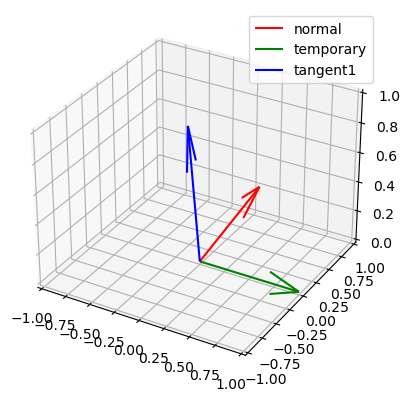

In [22]:


# Define vectors
#v1 = np.array([1, 0, 0])
#v2 = np.array([0, 1, 0])
#cross = np.cross(v1, v2)  # Cross product
#normal = np.array([0, 0, 1])  # Surface normal

# Plotting
fig, ax = plt.subplots(subplot_kw={'projection': '3d'}) 
ax.quiver(0, 0, 0, normal1[0] , normal1[2],normal1[1], color='r', label='normal')
ax.quiver(0, 0, 0, temp[0], temp[2], temp[1], color='g', label='temporary')
ax.quiver(0, 0, 0, tangent1[0],tangent1[2],tangent1[1] , color='b', label='tangent1')
#ax.quiver(0, 0, 0, *normal, color='m', label='Normal')
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_zlim(0, 1)
ax.legend()
plt.show()

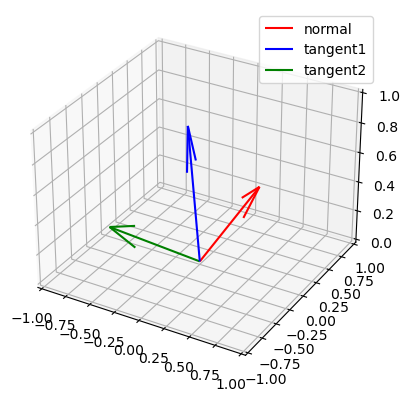

In [23]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.quiver(0, 0, 0, normal1[0] , normal1[2],normal1[1], color='r', label='normal')
ax.quiver(0, 0, 0, tangent1[0],tangent1[2],tangent1[1] , color='b', label='tangent1')
ax.quiver(0, 0, 0, tangent2[0],tangent2[2],tangent2[1] , color='g', label='tangent2')
#ax.quiver(0, 0, 0, *normal, color='m', label='Normal')
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_zlim(0, 1)
ax.legend()
plt.show()

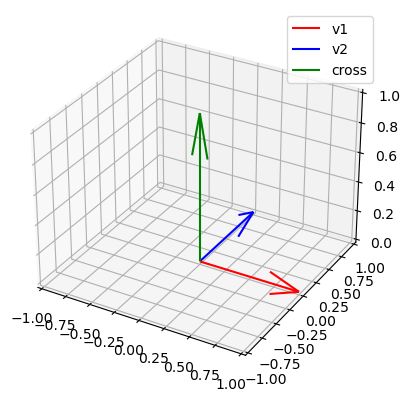

In [37]:
# Define vectors
v1 = np.array([1, 0, 0])
v2 = np.array([0, 1, 0])
cross = np.cross(v1, v2)  # Cross product
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.quiver(0, 0, 0, *v1, color='r', label='v1')
ax.quiver(0, 0, 0, *v2, color='b', label='v2')
ax.quiver(0, 0, 0, *cross, color='g', label='cross')
#ax.quiver(0, 0, 0, *normal, color='m', label='Normal')
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_zlim(0, 1)
ax.legend()
plt.show()

In [18]:
print(np.linalg.norm(tangent1))

1.0
